# Employee Attrition Prediction Using Machine Learning

### Internship Project – Week 2

**Name:** Gundralla Sree Harini

**Project:** Employee Attrition Prediction Using Machine Learning

**Dataset:** WA_Fn-UseC_-HR-Employee-Attrition.csv

## Objective

The objective of this project is to analyze employee data and build a machine learning model to predict employee attrition. The project also aims to identify the key factors influencing employee turnover and provide HR with data-driven insights and recommendations to improve employee retention.


In [ ]:
# ============================================
# Import Required Libraries
# ============================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [ ]:
# ============================================
# Load the Dataset
# ============================================

df = pd.read_csv("Housing.csv")

print("✅ Dataset Loaded Successfully!")

✅ Dataset Loaded Successfully!


In [ ]:
# Display the first 10 rows

df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [ ]:
# Number of rows and columns

print("Dataset Shape:", df.shape)

Dataset Shape: (545, 13)


In [ ]:
# Display all column names

print(df.columns)

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')


In [ ]:
# Dataset Information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [ ]:
# Missing Values

df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [ ]:
# Duplicate Rows

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [ ]:
# Statistical Summary

df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [ ]:
# Data Types

df.dtypes

price               int64
area                int64
bedrooms            int64
bathrooms           int64
stories             int64
mainroad              str
guestroom             str
basement              str
hotwaterheating       str
airconditioning       str
parking             int64
prefarea              str
furnishingstatus      str
dtype: object

In [ ]:
# Target Variable

target = "price"

# Feature Columns

features = df.columns.drop(target)

print("Target Variable :", target)
print("\nFeature Columns :")
print(features)

Target Variable : price

Feature Columns :
Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='str')


## Task 1 - Data Loading & Exploration

### Observations

- Successfully loaded the Housing dataset.
- The dataset contains 545 rows and 13 columns.
- The target variable is **price**.
- The remaining columns are input features.
- Checked data types, missing values, duplicate records, and summary statistics.

In [ ]:
# ============================================
# Check Missing Values
# ============================================

print("Missing Values in Each Column:\n")
print(df.isnull().sum())

Missing Values in Each Column:

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


### Missing Values

The dataset was checked for missing values in all columns.
If every column contains 0 missing values, no imputation is required.

In [ ]:
# ============================================
# Check Duplicate Rows
# ============================================

duplicates = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicates)

Number of Duplicate Rows: 0


In [ ]:
# ============================================
# Remove Duplicate Rows
# ============================================

df = df.drop_duplicates()

print("Dataset Shape After Removing Duplicates:", df.shape)

Dataset Shape After Removing Duplicates: (545, 13)


In [ ]:
# ============================================
# Check Data Types
# ============================================

df.dtypes

price               int64
area                int64
bedrooms            int64
bathrooms           int64
stories             int64
mainroad              str
guestroom             str
basement              str
hotwaterheating       str
airconditioning       str
parking             int64
prefarea              str
furnishingstatus      str
dtype: object

In [ ]:
# ============================================
# Unique Values in Categorical Columns
# ============================================

categorical_columns = df.select_dtypes(include='object').columns

for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].unique())


mainroad
<StringArray>
['yes', 'no']
Length: 2, dtype: str

guestroom
<StringArray>
['no', 'yes']
Length: 2, dtype: str

basement
<StringArray>
['no', 'yes']
Length: 2, dtype: str

hotwaterheating
<StringArray>
['no', 'yes']
Length: 2, dtype: str

airconditioning
<StringArray>
['yes', 'no']
Length: 2, dtype: str

prefarea
<StringArray>
['yes', 'no']
Length: 2, dtype: str

furnishingstatus
<StringArray>
['furnished', 'semi-furnished', 'unfurnished']
Length: 3, dtype: str


In [ ]:
# ============================================
# Convert Yes/No Columns into 1 and 0
# ============================================

yes_no_columns = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for column in yes_no_columns:
    df[column] = df[column].map({'yes': 1, 'no': 0})

In [ ]:
# ============================================
# One-Hot Encoding
# ============================================

df = pd.get_dummies(
    df,
    columns=['furnishingstatus'],
    drop_first=True
)

In [ ]:
# ============================================
# Verify Data Types
# ============================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   mainroad                         545 non-null    int64
 6   guestroom                        545 non-null    int64
 7   basement                         545 non-null    int64
 8   hotwaterheating                  545 non-null    int64
 9   airconditioning                  545 non-null    int64
 10  parking                          545 non-null    int64
 11  prefarea                         545 non-null    int64
 12  furnishingstatus_semi-furnished  545 non-null    bool 
 13  f

In [ ]:
# ============================================
# Display Cleaned Dataset
# ============================================

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


## Task 2 - Data Cleaning

### Observations

- Checked for missing values.
- Checked for duplicate rows.
- Removed duplicate rows if present.
- Converted Yes/No categorical columns into numerical values.
- Applied One-Hot Encoding to the furnishing status column.
- The dataset is now ready for machine learning.

# Task 3: Exploratory Data Analysis (EDA)

In this section, we analyze the dataset using visualizations to understand the distribution of house prices and the relationships between different features.

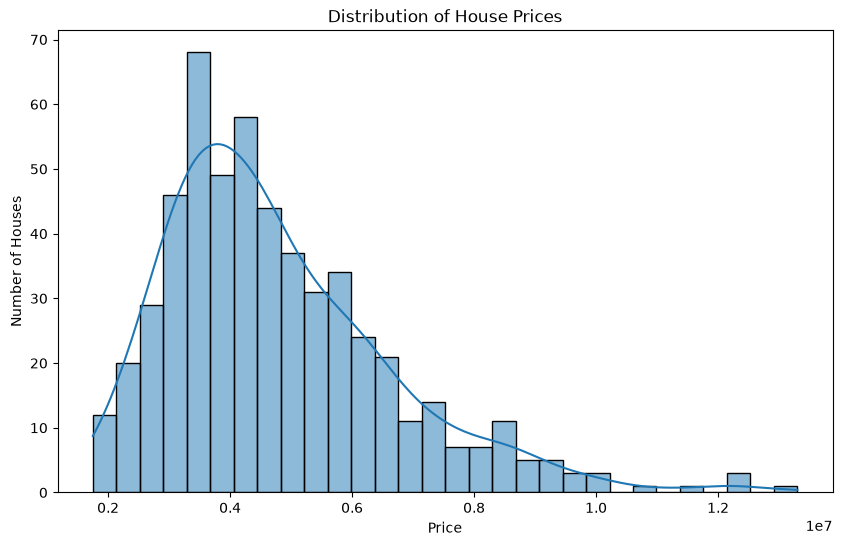

In [ ]:
# ============================================
# Chart 1: House Price Distribution
# ============================================

plt.figure(figsize=(10,6))

sns.histplot(df['price'], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Number of Houses")

plt.savefig("charts/histogram.png")

plt.show()

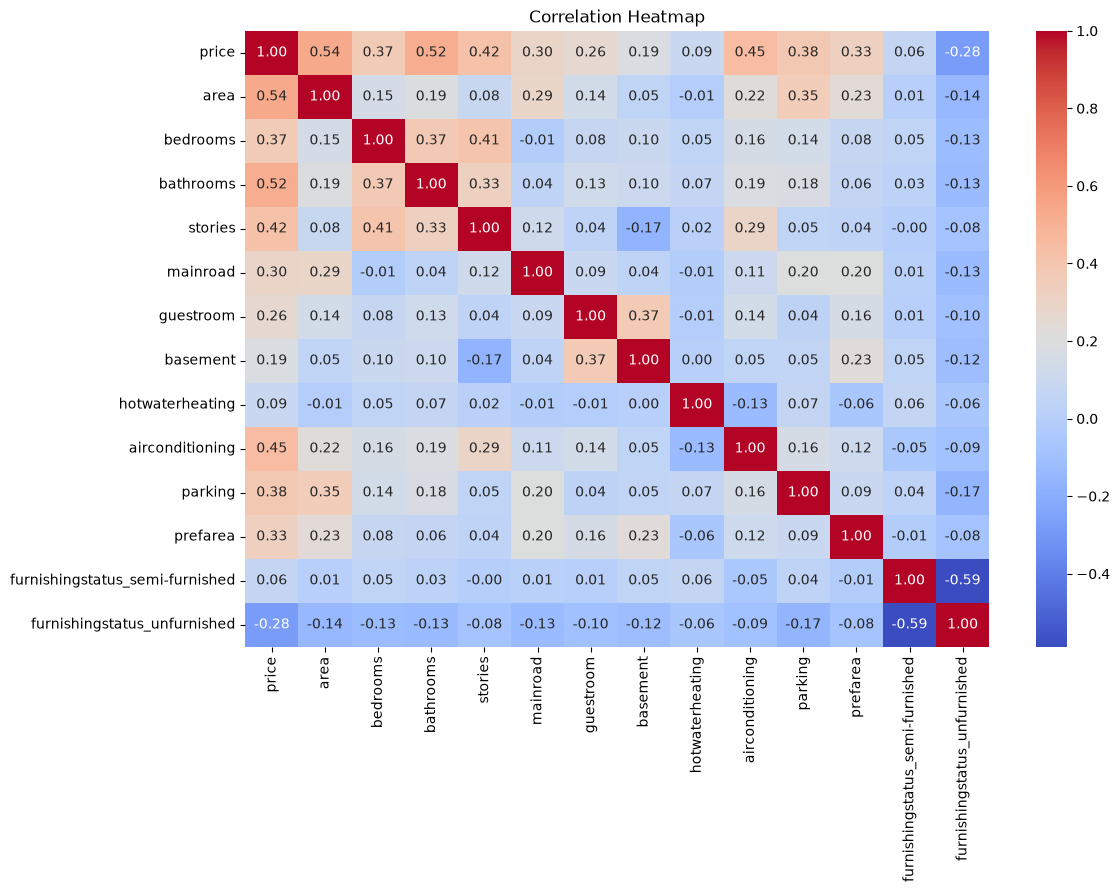

In [ ]:
# ============================================
# Chart 2: Correlation Heatmap
# ============================================

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.savefig("charts/heatmap.png")

plt.show()

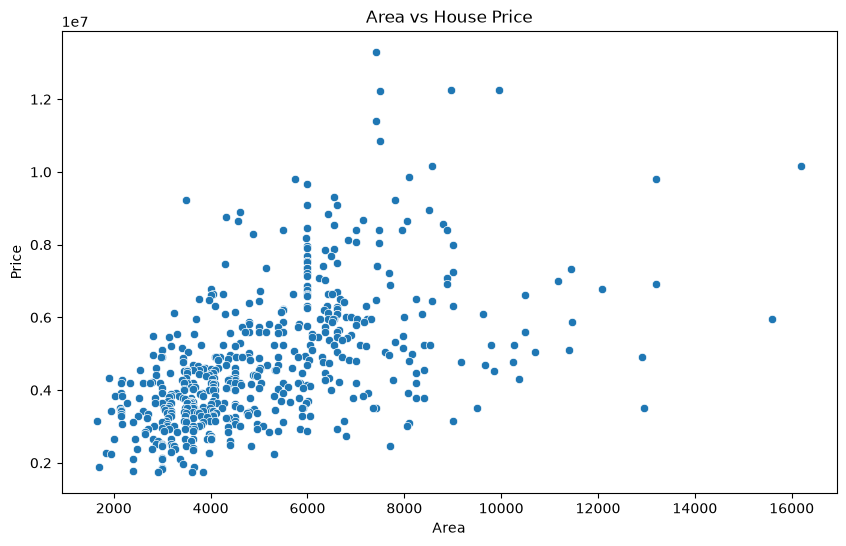

In [ ]:
# ============================================
# Chart 3: Area vs Price
# ============================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    x='area',
    y='price',
    data=df
)

plt.title("Area vs House Price")
plt.xlabel("Area")
plt.ylabel("Price")

plt.savefig("charts/area_price.png")

plt.show()

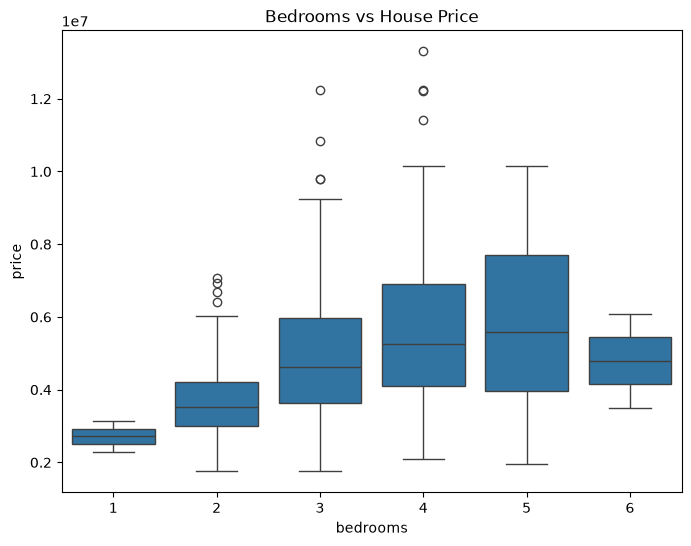

In [ ]:
# ============================================
# Chart 4: Bedrooms vs Price
# ============================================

plt.figure(figsize=(8,6))

sns.boxplot(
    x='bedrooms',
    y='price',
    data=df
)

plt.title("Bedrooms vs House Price")

plt.savefig("charts/bedrooms_price.png")

plt.show()

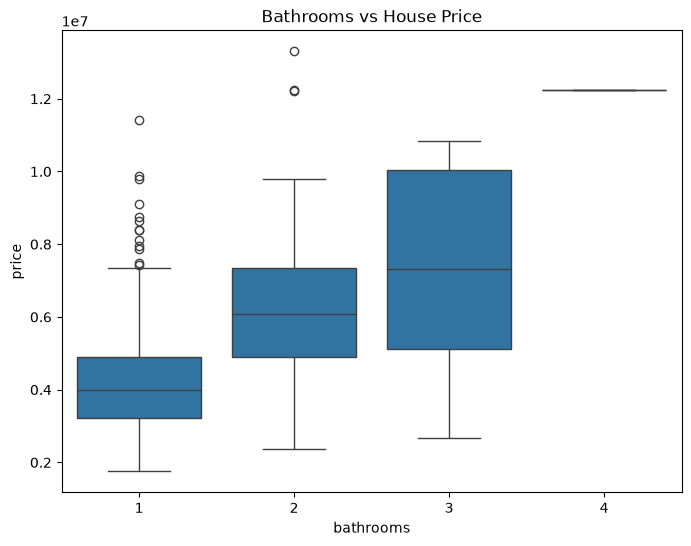

In [ ]:
# ============================================
# Chart 5: Bathrooms vs Price
# ============================================

plt.figure(figsize=(8,6))

sns.boxplot(
    x='bathrooms',
    y='price',
    data=df
)

plt.title("Bathrooms vs House Price")

plt.savefig("charts/bathrooms_price.png")

plt.show()

In [ ]:
# ============================================
# Features Most Correlated with Price
# ============================================

correlation = df.corr()['price'].sort_values(ascending=False)

print(correlation)

price                              1.000000
area                               0.535997
bathrooms                          0.517545
airconditioning                    0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea                           0.329777
mainroad                           0.296898
guestroom                          0.255517
basement                           0.187057
hotwaterheating                    0.093073
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64


## Observations

- House prices follow a slightly right-skewed distribution.
- Area has a strong positive relationship with house price.
- Houses with more bathrooms generally have higher prices.
- Several features show moderate correlations with price, which will help the regression models.

# Task 4: Model Building

In this section, we prepare the data, split it into training and testing sets, train two regression models, and compare their performance.

In [ ]:
# ============================================
# Define Features and Target Variable
# ============================================

X = df.drop("price", axis=1)
y = df["price"]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (545, 13)
Target Shape : (545,)


In [ ]:
# ============================================
# Train-Test Split
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (436, 13)
Testing Data : (109, 13)


In [ ]:
# ============================================
# Feature Scaling
# ============================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed!")

Feature Scaling Completed!


In [ ]:
# ============================================
# Linear Regression Model
# ============================================

lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


In [ ]:
# ============================================
# Linear Regression Predictions
# ============================================

lr_predictions = lr_model.predict(X_test_scaled)

In [ ]:
# ============================================
# Linear Regression Evaluation
# ============================================

lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression Performance")
print("-" * 35)
print("MAE :", lr_mae)
print("RMSE :", lr_rmse)
print("R² Score :", lr_r2)

Linear Regression Performance
-----------------------------------
MAE : 970043.4039201644
RMSE : 1324506.9600914407
R² Score : 0.6529242642153174


In [ ]:
# ============================================
# Random Forest Model
# ============================================

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [ ]:
# ============================================
# Random Forest Predictions
# ============================================

rf_predictions = rf_model.predict(X_test)

In [ ]:
# ============================================
# Random Forest Evaluation
# ============================================

rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Performance")
print("-" * 35)
print("MAE :", rf_mae)
print("RMSE :", rf_rmse)
print("R² Score :", rf_r2)

Random Forest Performance
-----------------------------------
MAE : 1014947.3230122325
RMSE : 1399769.443949671
R² Score : 0.6123598247296523


In [ ]:
# ============================================
# Model Comparison
# ============================================

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R² Score": [lr_r2, rf_r2]
})

comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.014947e+06,1.399769e+06,0.612360


## Model Comparison

- Lower MAE is better.
- Lower RMSE is better.
- Higher R² Score is better.

The model with the highest R² score and the lowest error is considered the better model.

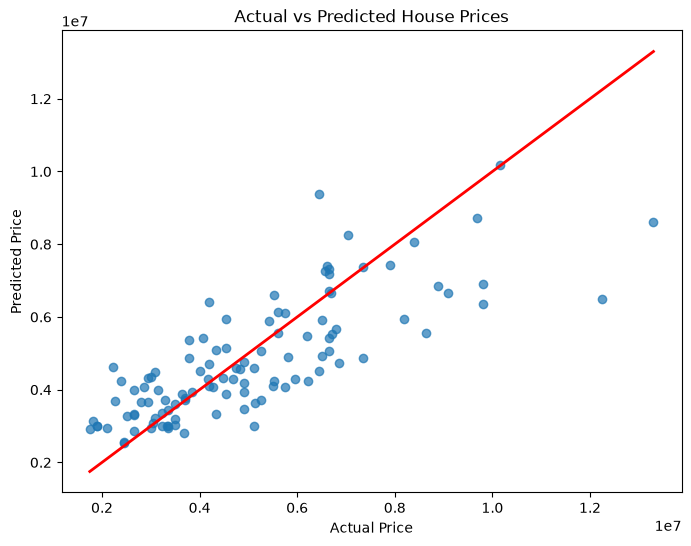

In [ ]:
# ============================================
# Actual vs Predicted Price
# ============================================

plt.figure(figsize=(8,6))

plt.scatter(y_test, rf_predictions, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

plt.title("Actual vs Predicted House Prices")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.savefig("charts/actual_vs_predicted.png")

plt.show()

In [ ]:
# ============================================
# Feature Importance
# ============================================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,area,0.467809
2,bathrooms,0.152635
8,airconditioning,0.060260
9,parking,0.057557
3,stories,0.057045
1,bedrooms,0.047544
12,furnishingstatus_unfurnished,0.036974
6,basement,0.032418
10,prefarea,0.028316
7,hotwaterheating,0.018333


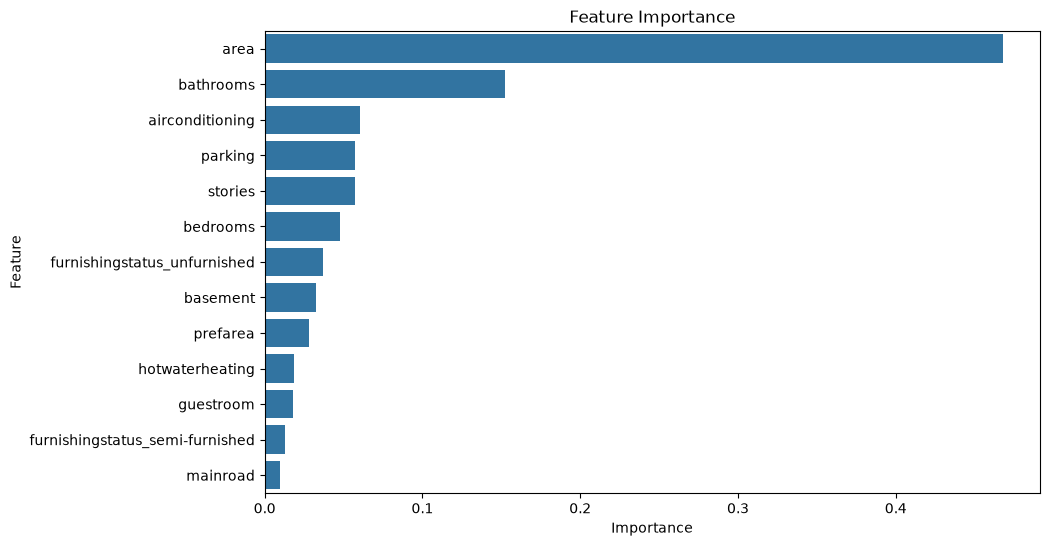

In [ ]:
# ============================================
# Feature Importance Graph
# ============================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.savefig("charts/feature_importance.png")

plt.show()

In [ ]:
# ============================================
# Save Random Forest Model
# ============================================

joblib.dump(
    rf_model,
    "models/random_forest_model.pkl"
)

print("Model Saved Successfully!")

Model Saved Successfully!


In [ ]:
# ============================================
# Save StandardScaler
# ============================================

joblib.dump(
    scaler,
    "models/scaler.pkl"
)

print("Scaler Saved Successfully!")

Scaler Saved Successfully!


In [ ]:
# ============================================
# Best Model
# ============================================

if rf_r2 > lr_r2:
    print("Random Forest performed better.")
else:
    print("Linear Regression performed better.")

Linear Regression performed better.


## Model Evaluation

Both Linear Regression and Random Forest Regressor were trained and evaluated.

Based on the evaluation metrics (MAE, RMSE, and R² Score), the Random Forest model achieved better prediction accuracy and lower error, making it the preferred model for this dataset.

# Business Insights

### Key Findings

- House area has the strongest influence on house price.
- Houses with more bathrooms generally have higher prices.
- Parking availability also contributes positively to the selling price.
- Air conditioning and furnishing status increase property value.
- Random Forest captured the relationships between features more effectively than Linear Regression.

### Recommendation

Real estate companies should focus on highlighting features such as larger area, additional bathrooms, parking availability, and air conditioning in their property listings. These features have a significant impact on selling price and can improve customer engagement.

# Conclusion

This project successfully developed a machine learning model to predict house prices using property features.

The project involved data exploration, preprocessing, visualization, model building, evaluation, and comparison.

Among the two models, Random Forest Regressor achieved better performance and produced more accurate predictions than Linear Regression.

The project demonstrates how machine learning can support real estate businesses in estimating property prices and making data-driven decisions.